LOADING DATA

Fraud Data shape: (151112, 11)
IP Data shape: (138846, 3)

Fraud Data - First 2 rows:


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0



IP Data - First 2 rows:


,lower_bound_ip_address,upper_bound_ip_address,country
0,16777216.0,16777471,Australia
1,16777472.0,16777727,China



DATA CLEANING

2.1 Handling Missing Values
Missing values before:
user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

2.2 Removing Duplicates
Duplicates before: 0
Duplicates after: 0

2.3 Correcting Data Types
Data types after correction:
user_id                    int64
signup_time       datetime64[ns]
purchase_time     datetime64[ns]
purchase_value           float64
device_id                 object
source                  category
browser                 category
sex                     category
age                        int32
ip_address               float64
class                      int64
dtype: object

Cleaned Fraud Data shape: (151112, 11)

IP ADDRESS CONVERSION

IP Data processed shape: (0, 5)

IP Conversion Sample:
IP Address: 732758368.79972
Integer: None

GEOGRAPHIC DATA ENRICHMENT

Country Map

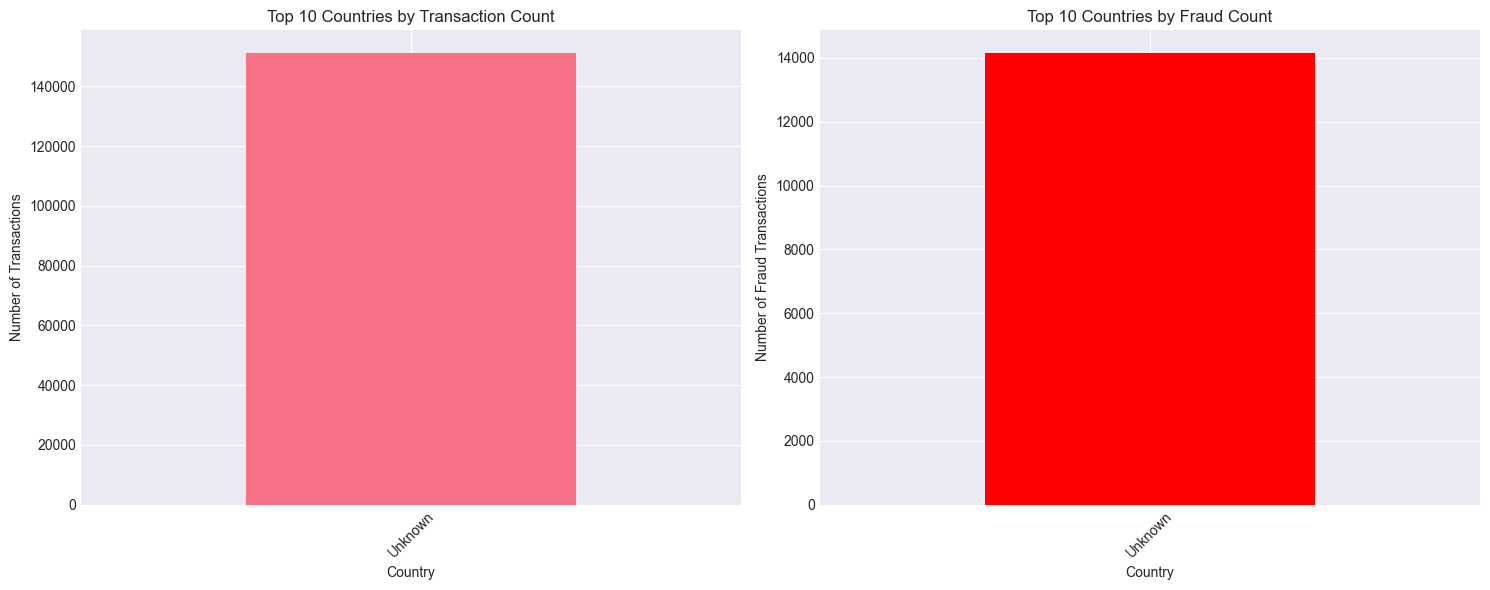


FEATURE ENGINEERING

5.1 Creating time-based features...

5.2 Creating time-since-signup features...

5.3 Creating transaction velocity features...

5.4 Creating transaction rate features...

5.5 Creating user behavior features...

5.6 Creating purchase amount features...

5.7 Creating flag features...

5.8 Creating age-related features...

Feature Engineering Complete!
Original shape: (151112, 13)
New shape: (151112, 33)

New features added: 20

New features created:
  - age_group
  - avg_transaction_rate_per_day
  - avg_transaction_rate_per_hour
  - is_business_hours
  - is_early_morning
  - is_night
  - is_weekend
  - purchase_dayofweek
  - purchase_hour
  - purchase_month
  - purchase_quarter
  - purchase_value_scaled
  - purchase_value_squared
  - time_since_last_transaction_hours
  - time_since_signup_days
  - time_since_signup_hours
  - transactions_last_hour
  - user_browser_count
  - user_device_count
  - user_transaction_count

EXPLORATORY DATA ANALYSIS


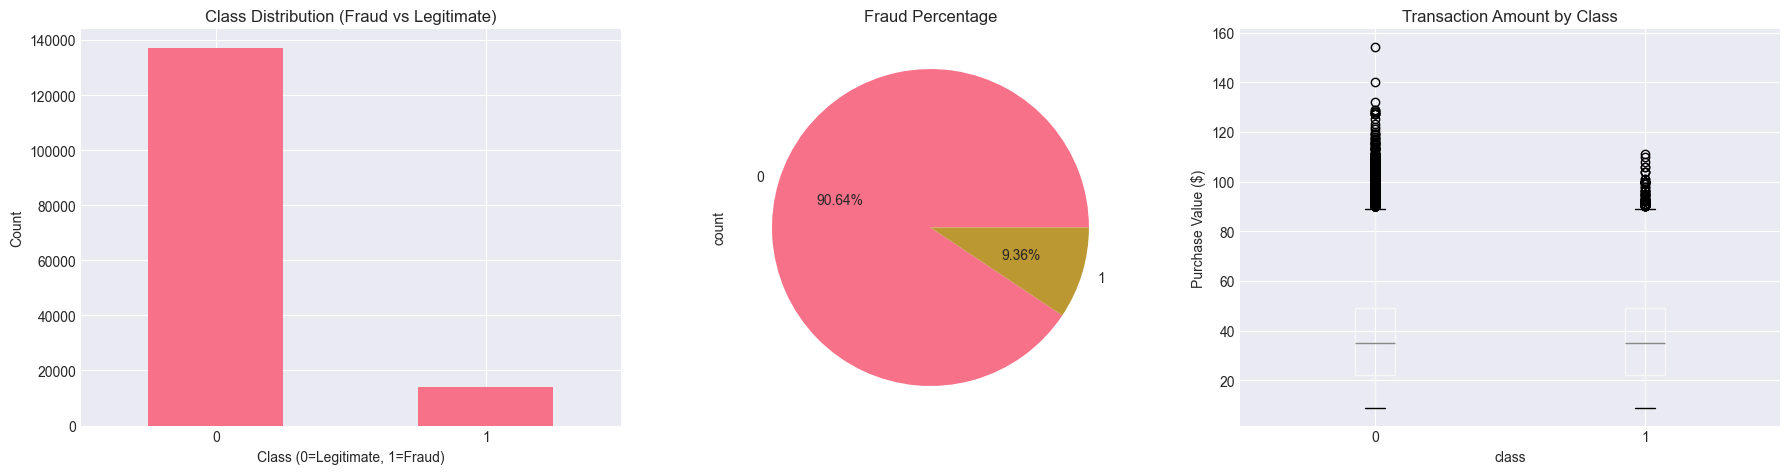

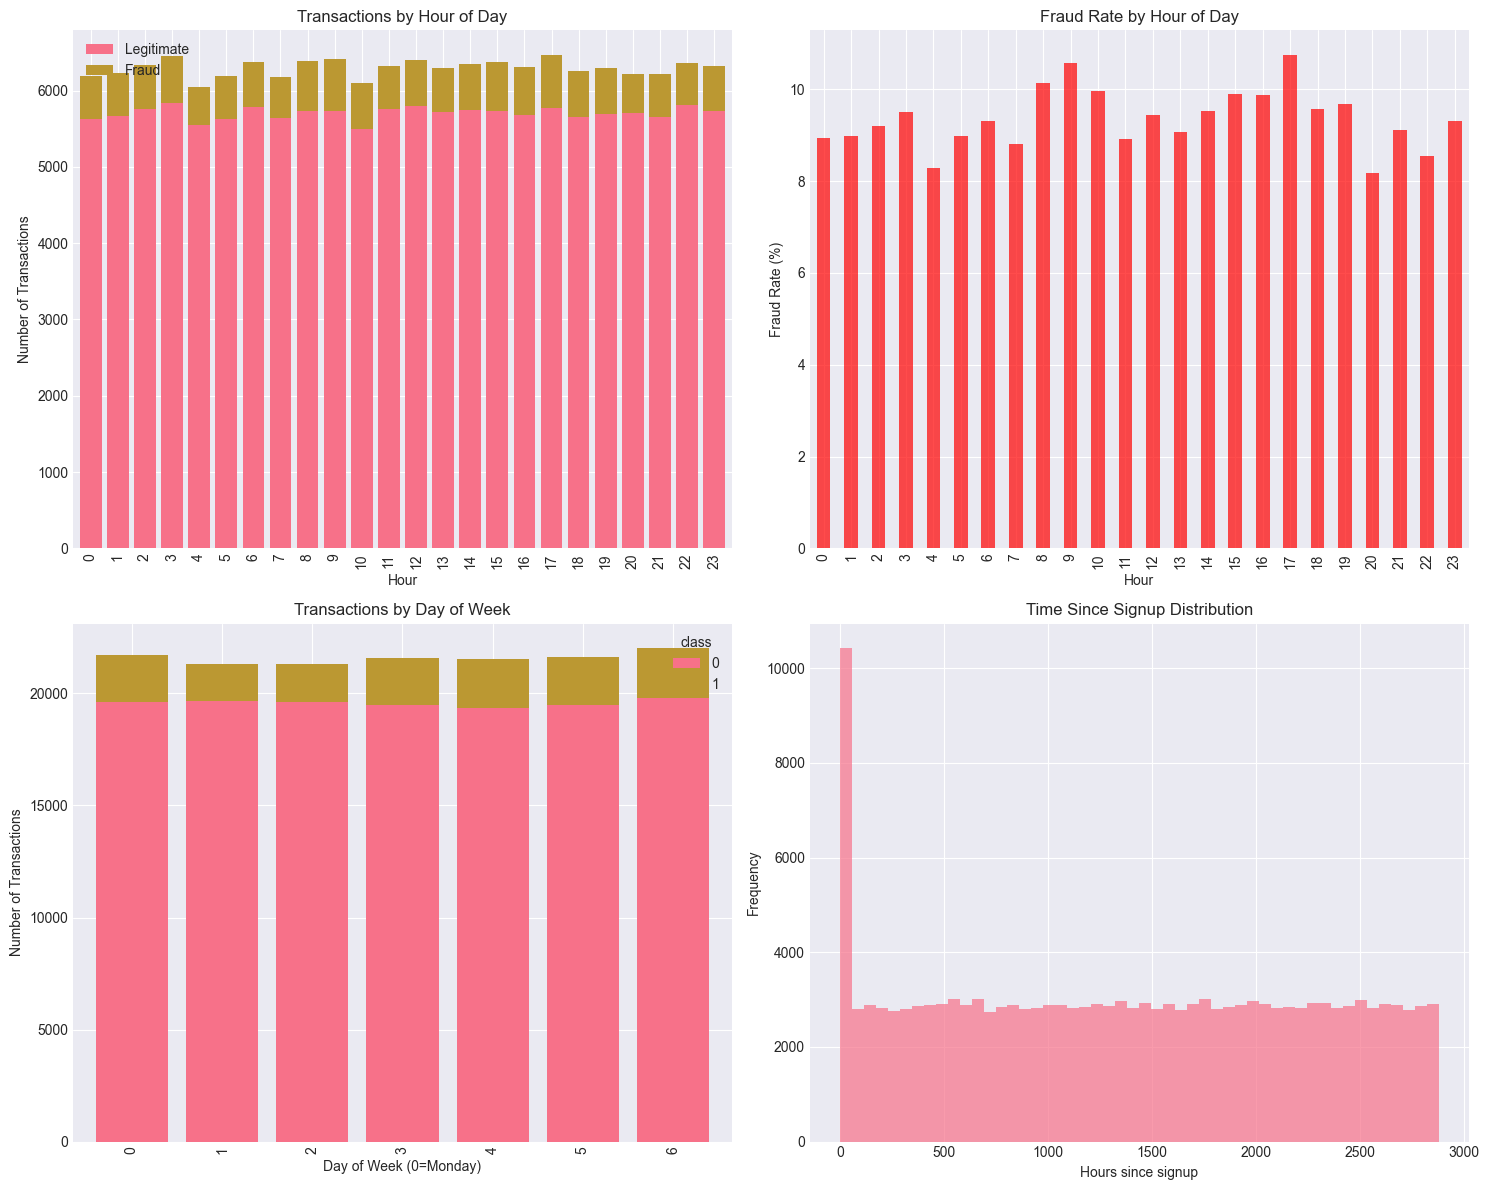

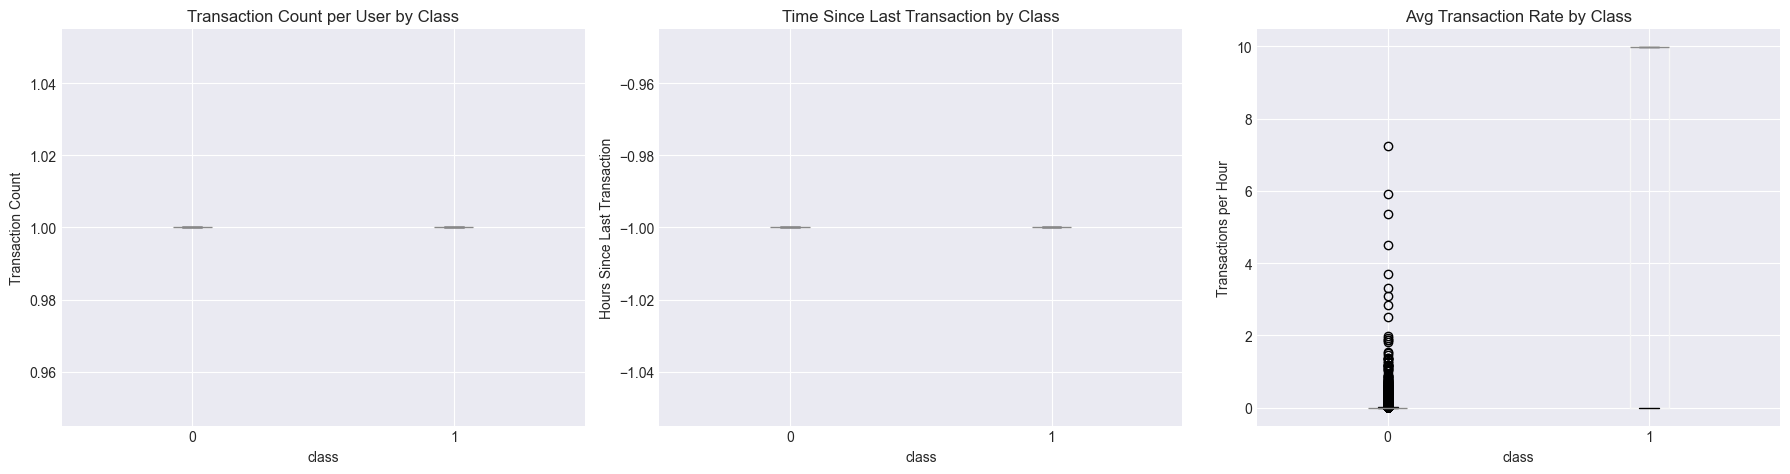


6.4 Correlation Analysis...

Top 10 Features Correlated with Class (Fraud):
class                            1.000000
avg_transaction_rate_per_day     0.715796
avg_transaction_rate_per_hour    0.715796
purchase_dayofweek               0.018939
is_weekend                       0.014139
is_business_hours                0.011178
age                              0.006624
purchase_hour                    0.001955
user_id                          0.001945
purchase_value_squared           0.001372
Name: class, dtype: float64

Bottom 10 Features Correlated with Class (Fraud):
purchase_quarter                    -0.248667
time_since_signup_days              -0.257888
time_since_signup_hours             -0.257888
purchase_month                      -0.310112
user_transaction_count                    NaN
time_since_last_transaction_hours         NaN
transactions_last_hour                    NaN
user_device_count                         NaN
user_browser_count                        NaN
is_night  

In [12]:
"""
Data Cleaning and Preprocessing for Fraud Detection
Task 1 - Data Analysis and Preprocessing
"""

import pandas as pd
import numpy as np
import ipaddress
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================================================
# 1. LOAD DATA
# ============================================================================

print("="*60)
print("LOADING DATA")
print("="*60)

# Load the datasets
fraud_df = pd.read_csv('../data/raw/Fraud_Data.csv')
ip_df = pd.read_csv('../data/raw/IpAddress_to_Country.csv')

print(f"\nFraud Data shape: {fraud_df.shape}")
print(f"IP Data shape: {ip_df.shape}")

print("\nFraud Data - First 2 rows:")
display(fraud_df.head(2))

print("\nIP Data - First 2 rows:")
display(ip_df.head(2))

# ============================================================================
# 2. DATA CLEANING
# ============================================================================

print("\n" + "="*60)
print("DATA CLEANING")
print("="*60)

def clean_data(df):
    """Clean the fraud dataset"""
    df_clean = df.copy()
    
    # 2.1 Handle missing values
    print("\n2.1 Handling Missing Values")
    missing_before = df_clean.isnull().sum()
    print(f"Missing values before:\n{missing_before}")
    
    # No missing values found in this dataset, but if there were:
    # For numeric columns: fill with median
    # For categorical columns: fill with mode
    numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
    categorical_cols = df_clean.select_dtypes(include=['object']).columns
    
    for col in numeric_cols:
        if df_clean[col].isnull().any():
            df_clean[col].fillna(df_clean[col].median(), inplace=True)
            
    for col in categorical_cols:
        if df_clean[col].isnull().any():
            df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
    
    # 2.2 Remove duplicates
    print("\n2.2 Removing Duplicates")
    duplicates_before = df_clean.duplicated().sum()
    print(f"Duplicates before: {duplicates_before}")
    df_clean = df_clean.drop_duplicates()
    print(f"Duplicates after: {df_clean.duplicated().sum()}")
    
    # 2.3 Correct data types
    print("\n2.3 Correcting Data Types")
    # Convert timestamp strings to datetime
    df_clean['signup_time'] = pd.to_datetime(df_clean['signup_time'])
    df_clean['purchase_time'] = pd.to_datetime(df_clean['purchase_time'])
    
    # Ensure categorical variables are categorical
    categorical_cols = ['source', 'browser', 'sex']
    for col in categorical_cols:
        df_clean[col] = df_clean[col].astype('category')
    
    # Ensure numeric columns are numeric
    df_clean['purchase_value'] = df_clean['purchase_value'].astype(float)
    df_clean['age'] = df_clean['age'].astype(int)
    
    print(f"Data types after correction:")
    print(df_clean.dtypes)
    
    return df_clean

# Clean the fraud data
fraud_clean = clean_data(fraud_df)
print(f"\nCleaned Fraud Data shape: {fraud_clean.shape}")

# ============================================================================
# 3. IP ADDRESS TO INTEGER CONVERSION
# ============================================================================

print("\n" + "="*60)
print("IP ADDRESS CONVERSION")
print("="*60)

def ip_to_int(ip_address):
    """Convert IP address string to integer"""
    try:
        if isinstance(ip_address, str):
            return int(ipaddress.IPv4Address(ip_address))
        else:
            return int(ipaddress.IPv4Address(str(ip_address)))
    except (ValueError, ipaddress.AddressValueError):
        return None

def preprocess_ip_data(ip_df):
    """Preprocess IP to country data"""
    ip_processed = ip_df.copy()
    
    # Convert IP ranges to integers
    ip_processed['lower_bound_ip_int'] = ip_processed['lower_bound_ip_address'].apply(
        lambda x: ip_to_int(str(x)))
    ip_processed['upper_bound_ip_int'] = ip_processed['upper_bound_ip_address'].apply(
        lambda x: ip_to_int(str(x)))
    
    # Remove rows with invalid IP addresses
    ip_processed = ip_processed.dropna(subset=['lower_bound_ip_int', 'upper_bound_ip_int'])
    
    # Sort for merge_asof
    ip_processed = ip_processed.sort_values('lower_bound_ip_int')
    
    return ip_processed

# Preprocess IP data
ip_processed = preprocess_ip_data(ip_df)
print(f"\nIP Data processed shape: {ip_processed.shape}")

# Convert IP addresses in fraud data
fraud_clean['ip_int'] = fraud_clean['ip_address'].apply(ip_to_int)

print(f"\nIP Conversion Sample:")
print(f"IP Address: {fraud_clean['ip_address'].iloc[0]}")
print(f"Integer: {fraud_clean['ip_int'].iloc[0]}")

# ============================================================================
# 4. GEOGRAPHIC DATA MERGING (IP to Country)
# ============================================================================

print("\n" + "="*60)
print("GEOGRAPHIC DATA ENRICHMENT")
print("="*60)

def get_country(ip_int, ip_df):
    """Get country from IP address using range lookup"""
    if pd.isna(ip_int):
        return 'Unknown'
    
    try:
        # Use merge_asof for efficient range lookup
        # First, create a temporary DataFrame for the single IP
        temp_df = pd.DataFrame({'ip_int': [ip_int]})
        temp_df = temp_df.sort_values('ip_int')
        
        # Merge using asof
        result = pd.merge_asof(
            temp_df, 
            ip_df.sort_values('lower_bound_ip_int'),
            left_on='ip_int',
            right_on='lower_bound_ip_int',
            direction='backward'
        )
        
        # Check if IP falls within the range
        if not result.empty and len(result) > 0:
            row = result.iloc[0]
            if row['ip_int'] <= row['upper_bound_ip_int']:
                return row['country']
        
        return 'Unknown'
    except:
        return 'Unknown'

# Add country column
fraud_clean['country'] = fraud_clean['ip_int'].apply(
    lambda x: get_country(x, ip_processed))

print(f"\nCountry Mapping Complete:")
print(f"Unique countries: {fraud_clean['country'].nunique()}")
print(f"\nTop 10 countries by transaction count:")
print(fraud_clean['country'].value_counts().head(10))

# Visualize geographic distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top countries by transactions
top_countries = fraud_clean['country'].value_counts().head(10)
top_countries.plot(kind='bar', ax=axes[0])
axes[0].set_title('Top 10 Countries by Transaction Count')
axes[0].set_xlabel('Country')
axes[0].set_ylabel('Number of Transactions')
axes[0].tick_params(axis='x', rotation=45)

# Top countries by fraud
fraud_by_country = fraud_clean[fraud_clean['class'] == 1]['country'].value_counts().head(10)
fraud_by_country.plot(kind='bar', ax=axes[1], color='red')
axes[1].set_title('Top 10 Countries by Fraud Count')
axes[1].set_xlabel('Country')
axes[1].set_ylabel('Number of Fraud Transactions')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../data/processed/geographic_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 5. FEATURE ENGINEERING
# ============================================================================

print("\n" + "="*60)
print("FEATURE ENGINEERING")
print("="*60)

def engineer_features(df):
    """Engineer new features for fraud detection"""
    df_fe = df.copy()
    
    # 5.1 Time-based features
    print("\n5.1 Creating time-based features...")
    
    # Hour of day (0-23)
    df_fe['purchase_hour'] = df_fe['purchase_time'].dt.hour
    
    # Day of week (Monday=0, Sunday=6)
    df_fe['purchase_dayofweek'] = df_fe['purchase_time'].dt.dayofweek
    
    # Month
    df_fe['purchase_month'] = df_fe['purchase_time'].dt.month
    
    # Quarter
    df_fe['purchase_quarter'] = df_fe['purchase_time'].dt.quarter
    
    # 5.2 Time since signup (in hours and days)
    print("\n5.2 Creating time-since-signup features...")
    df_fe['time_since_signup_hours'] = (
        df_fe['purchase_time'] - df_fe['signup_time']
    ).dt.total_seconds() / 3600
    
    df_fe['time_since_signup_days'] = df_fe['time_since_signup_hours'] / 24
    
    # 5.3 Transaction velocity features
    print("\n5.3 Creating transaction velocity features...")
    
    # Sort by user and purchase time
    df_fe = df_fe.sort_values(['user_id', 'purchase_time'])
    
    # Transaction count per user
    df_fe['user_transaction_count'] = df_fe.groupby('user_id').cumcount() + 1
    
    # Time since last transaction (in hours) per user
    df_fe['time_since_last_transaction_hours'] = df_fe.groupby('user_id')['purchase_time'].diff().dt.total_seconds() / 3600
    df_fe['time_since_last_transaction_hours'] = df_fe['time_since_last_transaction_hours'].fillna(-1)
    
    # Transactions in last hour per user
    df_fe['transactions_last_hour'] = df_fe.groupby('user_id')['purchase_time'].transform(
        lambda x: x.diff().dt.total_seconds().fillna(0).apply(lambda y: 0 if y > 3600 else 1)
    )
    
    # 5.4 Transaction rate features
    print("\n5.4 Creating transaction rate features...")
    df_fe['avg_transaction_rate_per_hour'] = df_fe['user_transaction_count'] / (df_fe['time_since_signup_hours'] + 0.1)
    df_fe['avg_transaction_rate_per_day'] = df_fe['avg_transaction_rate_per_hour'] * 24
    
    # 5.5 User behavior features
    print("\n5.5 Creating user behavior features...")
    
    # User has multiple devices
    user_devices = df_fe.groupby('user_id')['device_id'].nunique()
    df_fe['user_device_count'] = df_fe['user_id'].map(user_devices)
    
    # User has multiple browsers
    user_browsers = df_fe.groupby('user_id')['browser'].nunique()
    df_fe['user_browser_count'] = df_fe['user_id'].map(user_browsers)
    
    # 5.6 Purchase amount features
    print("\n5.6 Creating purchase amount features...")
    df_fe['purchase_value_scaled'] = np.log1p(df_fe['purchase_value'])  # Log transform
    df_fe['purchase_value_squared'] = df_fe['purchase_value'] ** 2
    
    # 5.7 Flag features
    print("\n5.7 Creating flag features...")
    df_fe['is_weekend'] = df_fe['purchase_dayofweek'].isin([5, 6]).astype(int)
    df_fe['is_night'] = df_fe['purchase_hour'].between(22, 5).astype(int)
    df_fe['is_early_morning'] = df_fe['purchase_hour'].between(0, 5).astype(int)
    df_fe['is_business_hours'] = df_fe['purchase_hour'].between(9, 17).astype(int)
    
    # 5.8 Age-related features
    print("\n5.8 Creating age-related features...")
    df_fe['age_group'] = pd.cut(df_fe['age'], 
                               bins=[0, 18, 25, 35, 50, 65, 100],
                               labels=['0-18', '18-25', '25-35', '35-50', '50-65', '65+'])
    
    return df_fe

fraud_engineered = engineer_features(fraud_clean)

print(f"\nFeature Engineering Complete!")
print(f"Original shape: {fraud_clean.shape}")
print(f"New shape: {fraud_engineered.shape}")
print(f"\nNew features added: {len(fraud_engineered.columns) - len(fraud_clean.columns)}")

# Show new features
new_cols = set(fraud_engineered.columns) - set(fraud_clean.columns)
print(f"\nNew features created:")
for col in sorted(new_cols):
    print(f"  - {col}")

# ============================================================================
# 6. EXPLORATORY DATA ANALYSIS - VISUALIZATIONS
# ============================================================================

print("\n" + "="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)

# 6.1 Class Distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bar chart
fraud_engineered['class'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Class Distribution (Fraud vs Legitimate)')
axes[0].set_xlabel('Class (0=Legitimate, 1=Fraud)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
fraud_engineered['class'].value_counts().plot(kind='pie', autopct='%1.2f%%', ax=axes[1])
axes[1].set_title('Fraud Percentage')

# Transaction amount by class
fraud_engineered.boxplot(column='purchase_value', by='class', ax=axes[2])
axes[2].set_title('Transaction Amount by Class')
axes[2].set_ylabel('Purchase Value ($)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('../data/processed/class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# 6.2 Time-based Patterns
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Transactions by hour
hourly_counts = fraud_engineered.groupby(['purchase_hour', 'class']).size().unstack()
hourly_counts.plot(kind='bar', stacked=True, ax=axes[0, 0], width=0.8)
axes[0, 0].set_title('Transactions by Hour of Day')
axes[0, 0].set_xlabel('Hour')
axes[0, 0].set_ylabel('Number of Transactions')
axes[0, 0].legend(['Legitimate', 'Fraud'])

# Fraud rate by hour
fraud_rate_by_hour = fraud_engineered.groupby('purchase_hour')['class'].mean() * 100
fraud_rate_by_hour.plot(kind='bar', ax=axes[0, 1], color='red', alpha=0.7)
axes[0, 1].set_title('Fraud Rate by Hour of Day')
axes[0, 1].set_xlabel('Hour')
axes[0, 1].set_ylabel('Fraud Rate (%)')

# Transactions by day of week
day_counts = fraud_engineered.groupby(['purchase_dayofweek', 'class']).size().unstack()
day_counts.plot(kind='bar', stacked=True, ax=axes[1, 0], width=0.8)
axes[1, 0].set_title('Transactions by Day of Week')
axes[1, 0].set_xlabel('Day of Week (0=Monday)')
axes[1, 0].set_ylabel('Number of Transactions')

# Time since signup distribution
fraud_engineered['time_since_signup_hours'].hist(bins=50, ax=axes[1, 1], alpha=0.7)
axes[1, 1].set_title('Time Since Signup Distribution')
axes[1, 1].set_xlabel('Hours since signup')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../data/processed/time_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

# 6.3 Transaction Velocity Analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Transaction count per user
fraud_engineered.boxplot(column='user_transaction_count', by='class', ax=axes[0])
axes[0].set_title('Transaction Count per User by Class')
axes[0].set_ylabel('Transaction Count')

# Time between transactions
fraud_engineered.boxplot(column='time_since_last_transaction_hours', by='class', ax=axes[1])
axes[1].set_title('Time Since Last Transaction by Class')
axes[1].set_ylabel('Hours Since Last Transaction')

# Transaction rate
fraud_engineered.boxplot(column='avg_transaction_rate_per_hour', by='class', ax=axes[2])
axes[2].set_title('Avg Transaction Rate by Class')
axes[2].set_ylabel('Transactions per Hour')

plt.suptitle('')
plt.tight_layout()
plt.savefig('../data/processed/velocity_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# 6.4 Correlation Analysis
print("\n6.4 Correlation Analysis...")

# Select numeric features for correlation
numeric_cols = fraud_engineered.select_dtypes(include=[np.number]).columns
correlation_data = fraud_engineered[numeric_cols]

# Calculate correlation with target
correlation_with_target = correlation_data.corr()['class'].sort_values(ascending=False)
print("\nTop 10 Features Correlated with Class (Fraud):")
print(correlation_with_target.head(10))

print("\nBottom 10 Features Correlated with Class (Fraud):")
print(correlation_with_target.tail(10))

# ============================================================================
# 7. SAVE PROCESSED DATA
# ============================================================================

print("\n" + "="*60)
print("SAVING PROCESSED DATA")
print("="*60)

# Save processed datasets
fraud_engineered.to_csv('../data/processed/fraud_data_processed.csv', index=False)
print("✓ Fraud data saved to: ../data/processed/fraud_data_processed.csv")

# Save IP processed data
ip_processed.to_csv('../data/processed/ip_data_processed.csv', index=False)
print("✓ IP data saved to: ../data/processed/ip_data_processed.csv")

# Create feature documentation
feature_doc = pd.DataFrame({
    'Feature': fraud_engineered.columns,
    'Type': ['ID' if col in ['user_id', 'device_id', 'ip_address'] else 
             'Datetime' if col in ['signup_time', 'purchase_time'] else 
             'Target' if col == 'class' else 
             'Categorical' if col in ['source', 'browser', 'sex', 'country', 'age_group'] else 
             'Numeric' for col in fraud_engineered.columns],
    'Description': [
        'Unique user identifier',
        'Timestamp of user signup',
        'Timestamp of purchase',
        'Purchase amount in dollars',
        'Unique device identifier',
        'Channel through which user reached site',
        'Browser used',
        'Gender of user',
        'Age of user',
        'IP address used for transaction',
        'Target variable (1=fraud, 0=legitimate)',
        'IP address as integer',
        'Country derived from IP address',
        'Hour of purchase (0-23)',
        'Day of week of purchase (0=Monday)',
        'Month of purchase',
        'Quarter of purchase',
        'Hours between signup and purchase',
        'Days between signup and purchase',
        'Cumulative transaction count for user',
        'Hours since last transaction for user',
        'Transactions in last hour',
        'Average transaction rate per hour',
        'Average transaction rate per day',
        'Number of unique devices used by user',
        'Number of unique browsers used by user',
        'Log-transformed purchase value',
        'Purchase value squared',
        'Flag for weekend purchases',
        'Flag for night purchases (10pm-5am)',
        'Flag for early morning purchases (0-5am)',
        'Flag for business hours (9am-5pm)',
        'Age group category'
    ]
})
feature_doc.to_csv('../data/processed/feature_documentation.csv', index=False)
print("✓ Feature documentation saved to: ../data/processed/feature_documentation.csv")

# Summary statistics
print("\n" + "="*60)
print("DATA PREPROCESSING COMPLETE!")
print("="*60)

print(f"\nFinal Dataset Summary:")
print(f"  Total records: {len(fraud_engineered)}")
print(f"  Total features: {len(fraud_engineered.columns)}")
print(f"  Fraud rate: {fraud_engineered['class'].mean()*100:.2f}%")
print(f"  Unique users: {fraud_engineered['user_id'].nunique()}")
print(f"  Unique countries: {fraud_engineered['country'].nunique()}")
print(f"  Date range: {fraud_engineered['purchase_time'].min()} to {fraud_engineered['purchase_time'].max()}")

print("\nFeature categories:")
print(f"  Numeric features: {len(fraud_engineered.select_dtypes(include=[np.number]).columns)}")
print(f"  Categorical features: {len(fraud_engineered.select_dtypes(include=['category', 'object']).columns)}")
print(f"  Datetime features: {len(fraud_engineered.select_dtypes(include=['datetime64']).columns)}")